# **1.서울 자전거 공유 수요 데이터셋**

서울시의 공공자전거 대여 서비스인 ‘따릉이’의 대여 수요를 예측하는 문제에 사용되는 데이터셋입니다. 특정 시간대와 날씨, 요일, 공휴일 여부, 기온, 습도 등 다양한 데이터를 활용하여 자전거 대여 수요를 예측합니다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### CP949
- Microsoft Windows의 한국어 문자 인코딩입니다.
- EUC-KR을 확장한 형태로, 더많은 한국어 문자(한자, 확장 문자 등)를 지원합니다.

In [4]:
DATA_PATH = Path('data/SeoulBikeData.csv')
bike_raw = pd.read_csv(DATA_PATH, encoding='cp949')
bike_raw

,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# **2. 데이터셋 컬럼**
```
Date : 연월일
Rented Bike count - 매 시간마다 대여한 자전거 수
Hour - 하루 중 시간
Temperature - 온도
Humidity - 습도 %
Windspeed - 풍속 m/s
Visibility - 가시거리 m
Dew point temperature - 이슬점 온도
Solar radiation - 태양 복사 MJ/m2
Rainfall - 강우량 mm
Snowfall - 적설량 cm
Seasons - 겨울, 봄, 여름, 가을
Holiday - 휴일/휴일 없음
Functional Day - 운영되지 않았던 날, 정상적으로 운영된 날
```

# **3. 기본정보 확인**

In [5]:
bike_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [6]:
bike_raw.describe()

,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [7]:
bike_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(캜),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(캜),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


In [8]:
bike_df = bike_raw.copy()
bike_df.columns = [
    'Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
    'Wind speed', 'Visibility', 'Dew point temperature',
    'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons',
    'Holiday', 'Functioning Day'
]
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [9]:
quality_report = pd.DataFrame({
    'missing_count': bike_df.isna().sum(),
    'missing_ratio': bike_df.isna().mean(),
    'nunique': bike_df.nunique()
})
print('중복 행 개수: ', bike_df.duplicated().sum())
print(quality_report)

중복 행 개수:  0
                       missing_count  missing_ratio  nunique
Date                               0            0.0      365
Rented Bike Count                  0            0.0     2166
Hour                               0            0.0       24
Temperature                        0            0.0      546
Humidity                           0            0.0       90
Wind speed                         0            0.0       65
Visibility                         0            0.0     1789
Dew point temperature              0            0.0      556
Solar Radiation                    0            0.0      345
Rainfall                           0            0.0       61
Snowfall                           0            0.0       51
Seasons                            0            0.0        4
Holiday                            0            0.0        2
Functioning Day                    0            0.0        2


# **4. EDA**
Exploratory Data analysis(탐색적 데이터 분석)의 약자로, 데이터를 본격적으로 모델링하거나 가설을 검증하기 전에 데이터의 구조, 특성, 패턴, 이상치, 변수 간의 관계를 이해하는 과정입니다.

### 1. EDA의 목적
- 데이터의 전체적인 구조 파악
- 결측치 확인
- 이상치 탐색
- 변수의 분포 확인
- 변수 간 관계 분석
- 데이터 품질 문제 발견
- 모델링 전에 전처리 방향 결정
- 새로운 가설 생성

### 2. 전체 과정

1. 데이터 불러오기
2. 데이터 구조 확인
3. 기초 통계 확인
4. 결측치 확인
5. 이상치 확인
6. 단변량 분석
7. 다변량 분석
8. 시각화
9. 인사이트 도출
10. 전처리 방향 결정



# 5. 날짜 처리와 피처 엔지니어링
Date는 문자열 그대로 모델에 넣을 수 없음. 날짜를 여러 의미있는 변수로 나눔
- year, month, day
- dayofweek: 월요일 0, 일요일 6
- is_weekend: 주말 여부
- hour_sin, hour_cos: 23시와 0시가 가깝다는 것을 모델에 알려주는 주기형 인코딩
- month_sin, month_cos: 12월과 1월이 가깝다는 것을 모델에 알려주는 주기형 인코딩

In [10]:
bike_df['Date'] = pd.to_datetime(bike_df['Date'], format='%d/%m/%Y')
bike_df['year'] = bike_df['Date'].dt.year
bike_df['month'] = bike_df['Date'].dt.month
bike_df['day'] = bike_df['Date'].dt.day
bike_df['dayofweek'] = bike_df['Date'].dt.dayofweek
bike_df['is_weekend'] = bike_df['dayofweek'].isin([5, 6]).astype(int)
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day,dayofweek,is_weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0


In [11]:
# 시간과 월은 반복되는 순환 구조
# 머신러닝 이해: 0 < 1 < 2 < ... < 23  실제 : 23 -> 0 (주기성 문제)
# 2 * np.pi * bike_df['Hour'] / 24 > 각도로 변환
# sin() 적용 > 0, 1, 0, -1, 0
# cos() 적용 > 1, 0, -1, 0, 1

bike_df['hour_sin'] = np.sin(2 * np.pi * bike_df['Hour'] / 24)
bike_df['hour_cos'] = np.cos(2 * np.pi * bike_df['Hour'] / 24)
bike_df['month_sin'] = np.sin(2 * np.pi * bike_df['month'] / 24)
bike_df['month_cos'] = np.cos(2 * np.pi * bike_df['month'] / 24)
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,...,Functioning Day,year,month,day,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.000000,1.000000,1.224647e-16,-1.0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.258819,0.965926,1.224647e-16,-1.0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,Yes,2017,12,1,4,0,0.500000,0.866025,1.224647e-16,-1.0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.707107,0.707107,1.224647e-16,-1.0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.866025,0.500000,1.224647e-16,-1.0


In [12]:
plt.rcParams['font.family'] = 'Malgun Gothic'

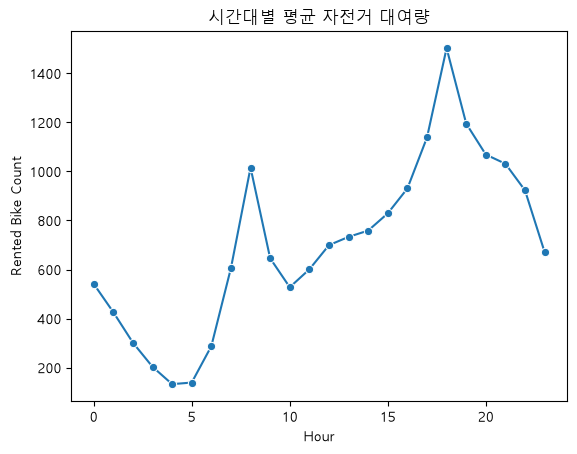

In [13]:
# 시간대별 평균 대여량
hourly_demand = bike_df.groupby('Hour')['Rented Bike Count'].mean().reset_index()
hourly_demand

sns.lineplot(data=hourly_demand, x='Hour', y='Rented Bike Count', marker='o')
plt.title('시간대별 평균 자전거 대여량')
plt.show()

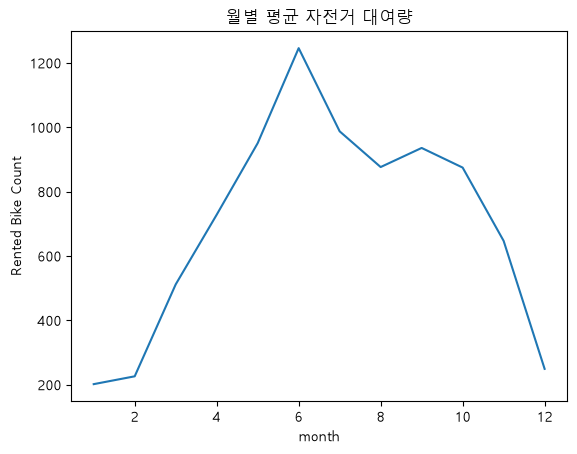

In [14]:
# 월별 평균 대여량
monthly_demand = bike_df.groupby('month')['Rented Bike Count'].mean().reset_index()

sns.lineplot(data=monthly_demand, x='month', y='Rented Bike Count')
plt.title('월별 평균 자전거 대여량')
plt.show()

> Seaborn의 barplot은 범주형 데이터(x)에 대해 수치형 데이터(y)의 통계 요약값을 계산하여 막대로 시각화하는 그래프로, 기본적으로 각 범주별 평균(mean)을 사용하며 평균의 불확실성을 나타내는 신뢰구간(error bar)을 함께 표시합니다. 내부적으로는 groupby와 집계 과정을 자동으로 수행하여 원본 데이터의 개수와 상관없이 범주 수만큼의 막대가 생성되며, estimator 옵션을 통해 평균 대신 합계·중앙값·개수 등으로 변경할 수 있고, hue를 사용하면 추가 범주에 따른 비교도 가능합니다. 즉, seaborn barplot은 값 자체가 아니라 집단 간 통계적 대표값을 비교하기 위한 시각화 도구입니다.

### ※ Seaborn의 barplot 을 읽는 법

1) 먼저 “막대가 뭘 뜻하는지”부터 확인합니다. Seaborn barplot의 막대 높이는 기본적으로 평균(mean) 입니다.
    - x축(또는 y축)에 있는 각 범주(category) 별로 y값(수치형)의 평균을 계산해서 그 평균을 막대 높이로 그립니다.
    > 따라서 “막대가 높다” = 그 범주의 평균이 크다 입니다. (원본 데이터의 한 개 값이 아니라, “집단의 대표값”입니다.)
2) 축을 읽어 “무엇을 비교하는지”를 정합니다
    - x축: 비교 대상(범주) → 예: 과일 종류, 요일, 지역, 등급
    - y축: 비교 기준(수치) → 예: 판매량 평균, 점수 평균, 가격 평균
3) 막대끼리 비교할 때는 “차이의 크기”를 봅니다. 막대의 높이 차이를 보고 해석합니다.
    - A 막대가 B보다 높다 → A의 평균이 더 크다
    - 막대 차이가 크다 → 집단 간 평균 차이가 크다
    - 비슷하다 → 큰 차이가 없다(적어도 평균 관점에서)
    > “평균이 비슷해도 데이터가 들쑥날쑥할 수 있다” → 그걸 보는 게 에러바입니다.
4) 에러바(error bar)는 “그 평균이 얼마나 믿을 만한지/흔들리는지”입니다. Seaborn barplot은 보통 막대 위아래에 선(에러바)가 그려집니다. 이 에러바는 설정에 따라 의미가 달라질 수 있지만(기본은 신뢰구간), 읽는 법은 공통입니다.
    - 해석: 이 데이터를 기반으로, 유사한 100가지의 케이스에서 95개 이상은 해당 범위에서 결과를 얻음을 의미
    - 평균(mean), 중앙값(median), 최빈값(mode)등의 다른 값들을 함께 고려했기 때문에 신뢰성 있는 수치임

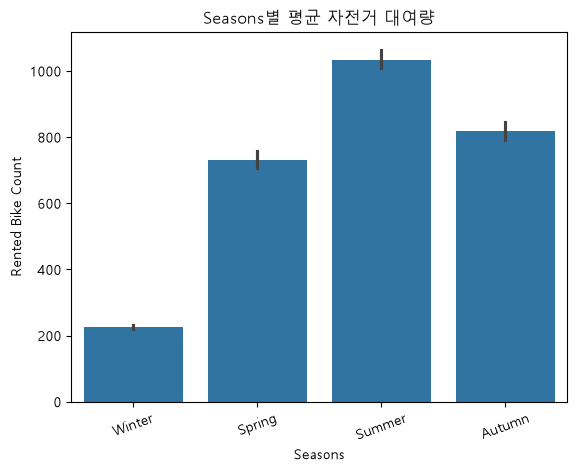

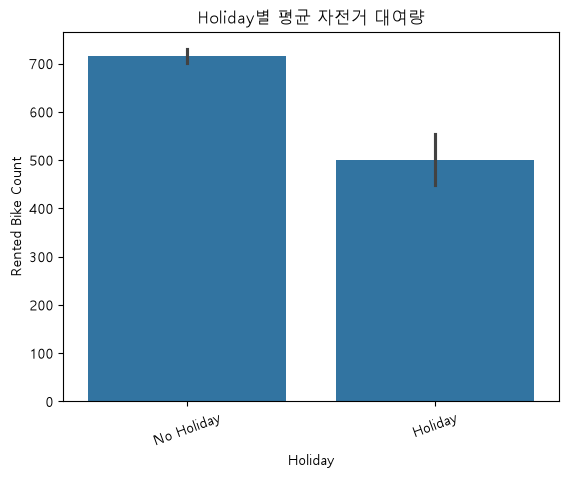

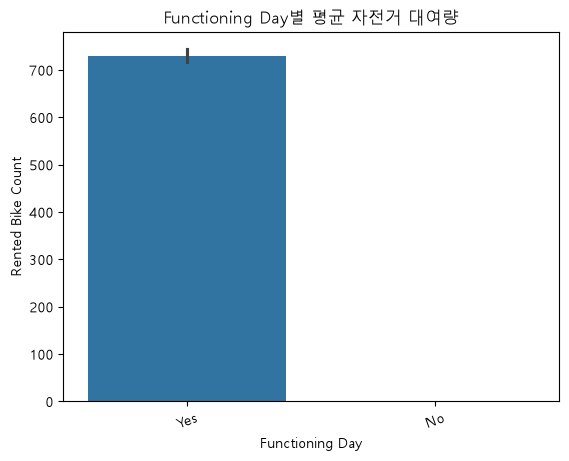

In [15]:
# 계절/공휴일/운영일별 평균 대여량
for col in ['Seasons', 'Holiday', 'Functioning Day']:
    sns.barplot(data=bike_df, x=col, y='Rented Bike Count')
    plt.title(f'{col}별 평균 자전거 대여량')
    plt.xticks(rotation=20)
    plt.show()

C:\Users\jmsya\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


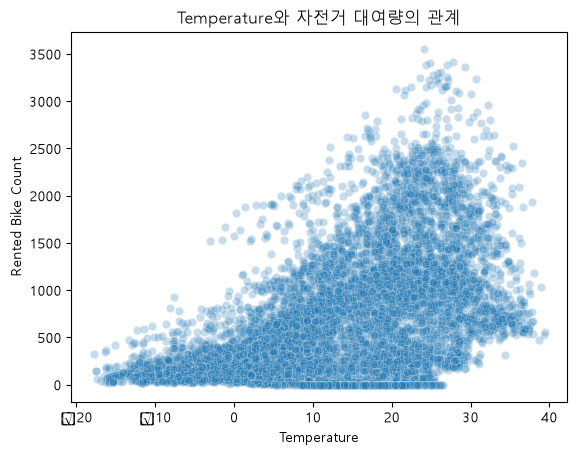

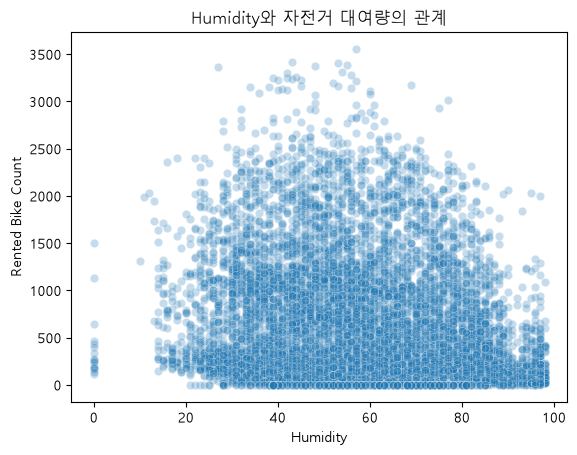

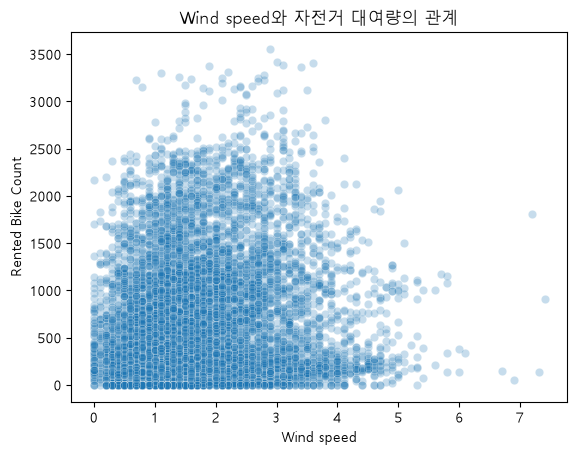

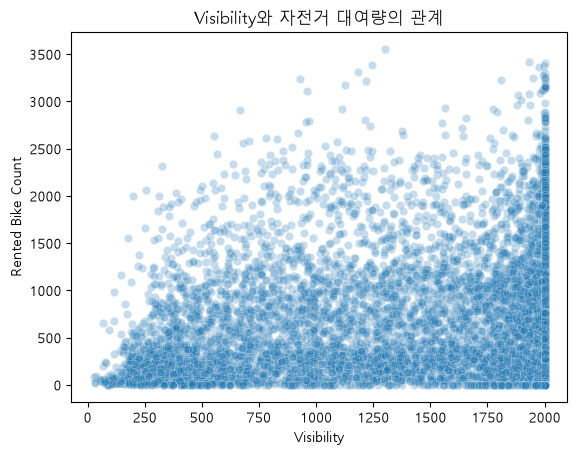

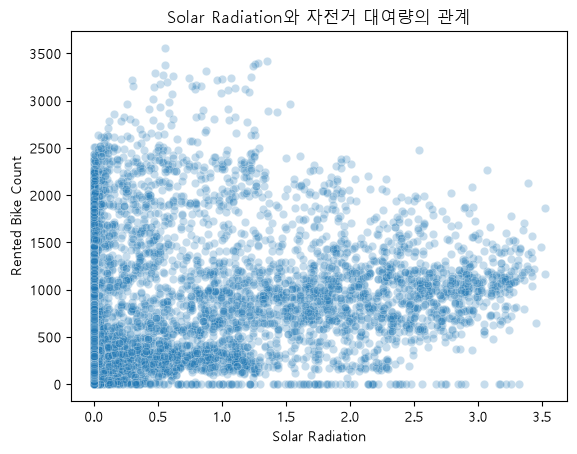

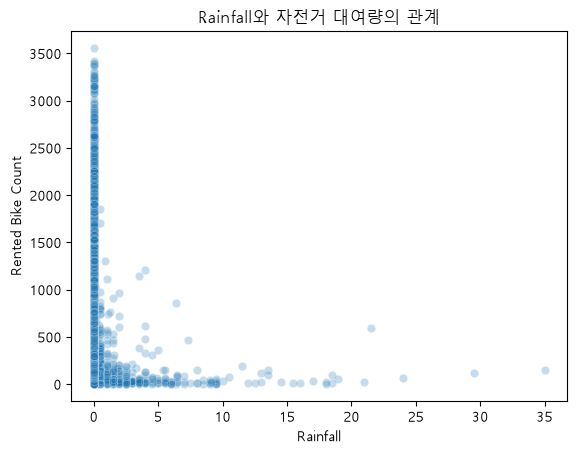

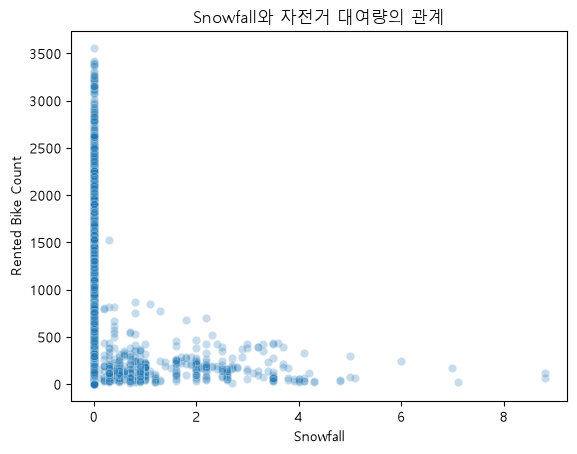

In [16]:
# 날씨 변수와 대여량 관계
weather_cols = ['Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Solar Radiation', 'Rainfall', 'Snowfall']

for col in weather_cols:
    sns.scatterplot(data=bike_df, x=col, y='Rented Bike Count', alpha=0.25)
    plt.title(f'{col}와 자전거 대여량의 관계')
    plt.show()

# **6. 운영일 데이터만 사용하기**
- 운영하지 않은 날은 실제 수요가 없어서 0에 가까움
- 운영일 수요를 예측하는 모델을 만들 때는 Functioning Day == 'Yes'  데이터만 사용하는 것이 해석하기 쉬움
- 운영 여부 판단 또는 운영 캘린더 확인
- 운영하는 날에 한해 수요 에측

In [17]:
model_df = bike_df[bike_df['Functioning Day'] == 'Yes'].copy()
model_df = model_df.drop(columns=['Functioning Day'])
print('전체 데이터 크기: ', bike_df.shape)
print('운영일 데이어 크기: ', model_df.shape)

전체 데이터 크기:  (8760, 23)
운영일 데이어 크기:  (8465, 22)


# **7. 학습/검증 데이터 분할**
- 시간 기준 분할: 랜덤 분할은 미래 시점의 데이터가 학습 데이터에 섞일 수 있음. 수요 예측은 보통 과거를 보고 미래를 예측해야 하므로, 실무에서는 시간 순서 기준 검증이 더 자연스러움


In [18]:
target = "Rented Bike Count"

model_df = model_df.sort_values(['Date', 'Hour']).reset_index(drop=True)

feature_cols = [col for col in model_df.columns if col not in [target, 'Date']]
X = model_df[feature_cols]
y = model_df[target]

split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("학습 데이터: ", X_train.shape, y_train.shape)
print("테스트 데이터: ", X_test.shape, y_test.shape)
print("학습 기간: ", model_df.loc[:split_idx-1, 'Date'].min(), model_df.loc[:split_idx-1, 'Date'].max())
print("테스트 기간: ", model_df.loc[split_idx:, 'Date'].min(), model_df.loc[split_idx:, 'Date'].max())

학습 데이터:  (6772, 20) (6772,)
테스트 데이터:  (1693, 20) (1693,)
학습 기간:  2017-12-01 00:00:00 2018-09-11 00:00:00
테스트 기간:  2018-09-11 00:00:00 2018-11-30 00:00:00


# **8. 전처리 파이프라인 구성**


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [20]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
print('숫자형 변수: ', numeric_features)
print('범주형 변수: ', categorical_features)

숫자형 변수:  ['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
범주형 변수:  ['Seasons', 'Holiday']


※ 데이터 스케일링

데이터 스케일링은 서로 다른 범위와 단위를 가진 데이터를 일정한 범위로 변환하여 모델 학습을 더 효율적으로 수행할 수 있도록 만드는 전처리 과정입니다. 주로 변수 간의 값의 크기 차이가 클 때 발생하는 불균형을 해결하기 위해 사용되며, 대표적인 방법으로 표준화(Standardization)와 정규화(Normalization)가 있습니다. 스케일링을 통해 학습 속도를 높이고, 기울기 소실(Gradient Vanishing) 문제를 완화하며, 특정 변수에 모델이 과도하게 의존하는 것을 방지할 수 있습니다.

※ 표준화

표준화(Standardization)는 데이터의 평균을 0으로, 표준편차를 1로 변환하여 모든 변수가 동일한 척도를 갖도록 만드는 데이터 전처리 기법입니다. 주로 데이터의 분포가 정규 분포를 따를 때 효과적이며, 값의 크기나 단위가 서로 다른 변수를 비교하거나 머신러닝 알고리즘(예: 로지스틱 회귀, SVM)에서 최적의 성능을 내기 위해 사용됩니다.

![표준화](./data/표준화.png)

※ 정규화

정규화(Normalization)는 데이터의 값을 특정 범위(주로 0과 1 사이)로 변환하여 변수 간의 스케일 차이를 줄이는 데이터 전처리 기법입니다. 이는 주로 최소값과 최대값을 사용해 데이터를 조정하며, 대표적인 방법으로 Min-Max Scaling이 있습니다.

![정규화](./data/정규화.png)

In [21]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocess_for_linear = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 트리 계열 모델은 스케일링이 필수가 아님
tree_numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median'))
])

preprocess_for_tree = ColumnTransformer(
    transformers = [
        ('num', tree_numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# **9. 평가 함수 만들기**

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
def evaluate_regression(model, X_test, y_test, model_name):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return {
        'model' : model_name,
        'MAE' : mae,
        'RMSE' : rmse,
        'R2' : r2
    }

def plot_actual_vs_pred(model, X_test, y_test, title):
    pred = model.predict(X_test)
    sns.scatterplot(x=y_test, y=pred, alpha=0.35)
    min_value = min(y_test.min(), pred.min())
    max_value = max(y_test.max(), pred.max())
    plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
    plt.xlabel('실제값')
    plt.ylabel('예측값')
    plt.title(title)
    plt.show()

# **10. 기본 모델 비교 실험**

- `DummyRegressor`: 기준선 모델입니다. 평균만 예측합니다. 이 모델보다 못하면 의미 있는 모델이 아닙니다.
- `LinearRegression`: 선형 관계를 기준으로 예측합니다.
- `Ridge`: 선형회귀에 규제를 추가한 모델입니다.
- `DecisionTreeRegressor`: 기존 노트북의 중심 모델입니다.
- `RandomForestRegressor`: 여러 결정트리를 평균내는 앙상블 모델입니다.
- `ExtraTreesRegressor`: 랜덤성을 더 강하게 주는 트리 앙상블 모델입니다.
- `GradientBoostingRegressor`: 이전 모델의 오차를 다음 모델이 보완하는 방식입니다.
- `HistGradientBoostingRegressor`: 대용량 데이터에서도 빠른 부스팅 계열 모델입니다.

In [24]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

RANDOM_STATE = 2026

In [25]:
models = {
    'Dummy': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    'LinearRegression': Pipeline([
        ('preprocess', preprocess_for_linear),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocess', preprocess_for_linear),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    'DecisionTree': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]),
    'RandomForest': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'ExtraTrees': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'GradientBoosting': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]),
    'HistGradientBoosting': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ])
}

In [26]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    results.append(evaluate_regression(model, X_test, y_test, name))

result_df = pd.DataFrame(results).sort_values('RMSE')
result_df

,model,MAE,RMSE,R2
5,ExtraTrees,149.603538,224.408692,0.859799
7,HistGradientBoosting,222.667163,299.998648,0.749441
4,RandomForest,246.030016,340.013642,0.678143
6,GradientBoosting,272.646372,376.298436,0.605783
3,DecisionTree,308.330774,419.317566,0.510495
0,Dummy,491.505685,634.408696,-0.120493
2,Ridge,935.262607,1095.898199,-2.343576
1,LinearRegression,1119.109559,1310.117009,-3.778493


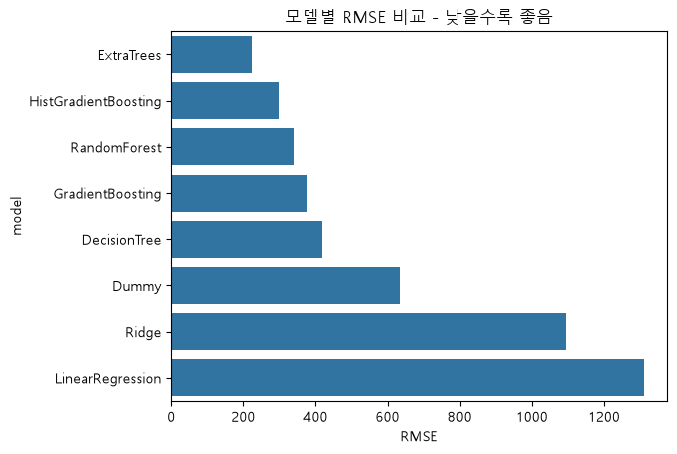

In [27]:
sns.barplot(data=result_df, x='RMSE', y='model')
plt.title('모델별 RMSE 비교 - 낮을수록 좋음')
plt.show()

# **11. 결정 트리**
결정 트리(Decision Tree)는 데이터를 기반으로 의사결정을 수행하는 트리 구조의 예측 모델입니다. 루트 노드(root node)에서 시작해 각 노드는 특정 특성(feature)의 조건에 따라 가지(branch)로 분기되며, 최종적으로 리프 노드(leaf node)에 도달해 예측 결과(클래스나 값)를 도출합니다. 주로 분류(Classification)와 회귀(Regression) 문제에 사용되며, 데이터의 패턴을 직관적으로 시각화할 수 있어 해석이 용이합니다. 하지만 트리가 너무 깊어지면 과적합(overfitting) 문제가 발생할 수 있으므로 가지치기(pruning)나 최대 깊이 설정 등으로 제어해야 합니다.

### 결정 트리 학습 순서
1. 전체 데이터셋을 하나의 노드로 시작합니다.
2. 최적의 특성(feature)과 분할 기준(threshold)을 찾아 첫 번째 분할을 수행합니다.
- 분류 (Classification):
    - Gini 불순도(Gini Impurity)
    - 엔트로피(Entropy)
- 회귀 (Regression):
    - 평균 제곱 오차(Mean Squared Error, MSE)
    - 절대 평균 오차(Mean Absolute Error, MAE)
3. 각 하위 노드에 대해 위 단계를 반복합니다.
4. 이 과정을 통해 트리는 여러 깊이로 성장합니다.
5. 모든 노드가 더 이상 나눌 수 없거나 특정 조건(max_depth, min_samples_split)을 만족할 때까지 반복됩니다.
6. 더 이상 분할이 불가능할 때 리프 노드가 생성됩니다.
    - 분류 문제: 가장 많은 클래스가 있는 클래스를 예측값으로 사용
    - 회귀 문제: 평균값을 예측값으로 사용

# **12. 결정트리 하이퍼파라미터 튜닝**
결정트리는 아무 제한 없이 학습하면 훈련 데이터에 과적합되기 쉽습니다.
- max_depth: 트리의 최대 깊이
- min_samples_split: 노드를 나누기 위한 최소 샘플 수
- min_samples_leaf: 리프 노드에 있어야 하는 최소 샘플 수
- GridSearchCV로 여러 조합을 비교

In [28]:
from sklearn.model_selection import GridSearchCV


In [29]:
dt_pipeline = Pipeline([
    ('preprocess', preprocess_for_tree),
    ('model', DecisionTreeRegressor(random_state=2026))
])

param_grid = {
    'model__max_depth': [4, 6, 8, 10, 12, None],
    'model__min_samples_split': [2, 10, 30, 50],
    'model__min_samples_leaf': [1, 5, 10, 20, 30]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)

In [30]:
dt_grid.fit(X_train, y_train);

In [31]:
print("Best Params: ", dt_grid.best_params_) # 가장 좋은 하이퍼파라미터 출력
print("Best CV RMSE: ", -dt_grid.best_score_) # scoring이 negative RMSE였기 때문에 음수 부호 제거

Best Params:  {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 50}
Best CV RMSE:  403.36600454110413


In [32]:
# dt_grid.best_estimator_: 최고 성능 모델 자체
tuned_dt_result = evaluate_regression(dt_grid.best_estimator_, X_test, y_test, 'DecisionTree_Tuned')
tuned_dt_result

{'model': 'DecisionTree_Tuned',
 'MAE': 314.94750729083466,
 'RMSE': np.float64(424.43338034634263),
 'R2': 0.4984781553667099}

In [33]:
# 튜닝한 결정트리 결과를 기존 비교표에 추가
final_result_df = pd.concat([result_df, pd.DataFrame([tuned_dt_result])], ignore_index=True)
final_result_df = final_result_df.sort_values('RMSE').reset_index(drop=True)
final_result_df

,model,MAE,RMSE,R2
0,ExtraTrees,149.603538,224.408692,0.859799
1,HistGradientBoosting,222.667163,299.998648,0.749441
2,RandomForest,246.030016,340.013642,0.678143
3,GradientBoosting,272.646372,376.298436,0.605783
4,DecisionTree,308.330774,419.317566,0.510495
5,DecisionTree_Tuned,314.947507,424.433380,0.498478
6,Dummy,491.505685,634.408696,-0.120493
7,Ridge,935.262607,1095.898199,-2.343576
8,LinearRegression,1119.109559,1310.117009,-3.778493


가장 RMSE가 낮은 모델: ExtraTrees


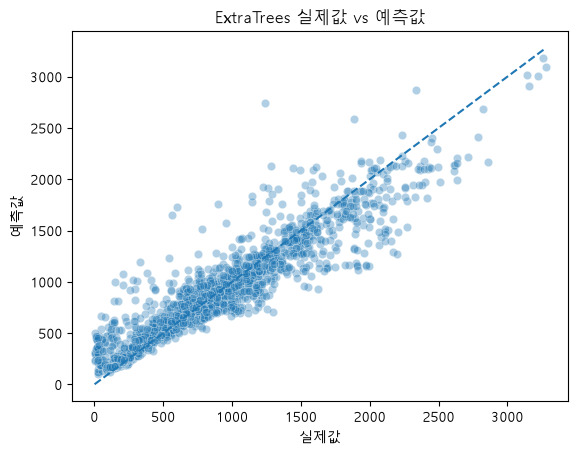

In [34]:
best_model_name = final_result_df.iloc[0]['model']
print('가장 RMSE가 낮은 모델:', best_model_name)

if best_model_name == 'DecisionTree_Tuned':
    best_model = dt_grid.best_estimator_
else:
    best_model = models[best_model_name]

plot_actual_vs_pred(best_model, X_test, y_test, f'{best_model_name} 실제값 vs 예측값')

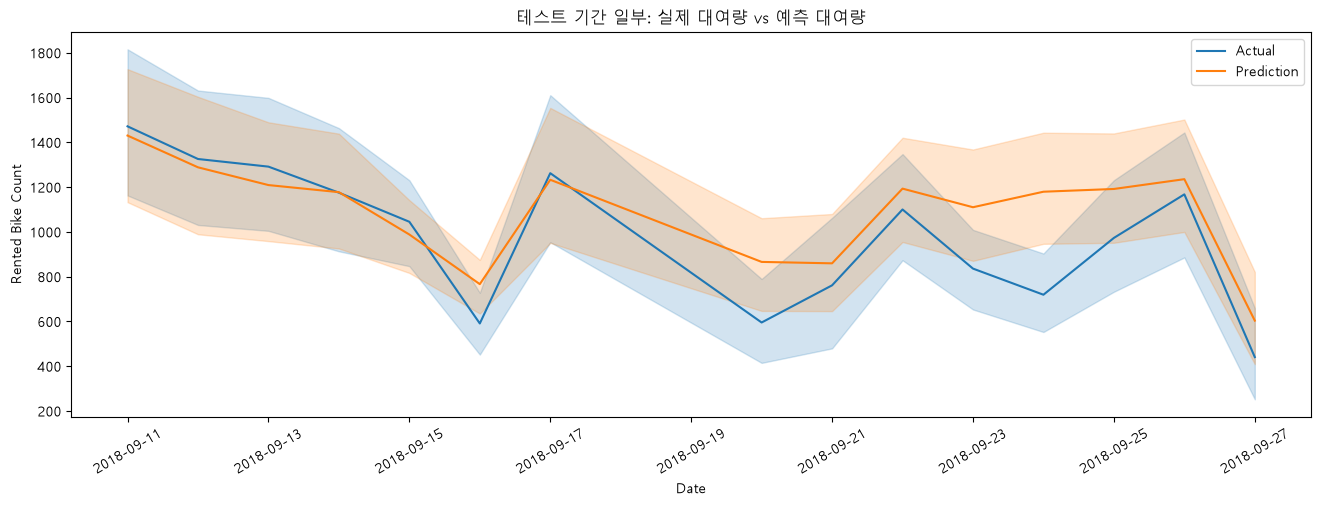

In [35]:
# 테스트 기간의 실제값과 예측값을 시간 순서로 비교
pred = best_model.predict(X_test)
compare_df = model_df.iloc[split_idx:].copy()
compare_df['prediction'] = pred

sample_compare = compare_df.head(24*14) # 테스트 기간 앞 2주

plt.figure(figsize=(16, 5))
sns.lineplot(data=sample_compare, x='Date', y='Rented Bike Count', label='Actual')
sns.lineplot(data=sample_compare, x='Date', y='prediction', label='Prediction')
plt.title('테스트 기간 일부: 실제 대여량 vs 예측 대여량')
plt.xticks(rotation=30)
plt.show()

# **13. 피처 중요도 확인**
트리 계열 모델에서는 피처 중요도를 확인할 수 있습니다.
- 피처 중요도는 인과관계를 의미하지 않습니다.
- One-Hot Encoding된 범주형 변수는 여러 개의 컬럼으로 나뉘어 표시됩니다.
- 상관관계가 강한 변수끼리는 중요도가 나뉘거나 한쪽으로 몰릴 수 있습니다.

,feature,importance
14,hour_sin,0.157559
21,Seasons_Winter,0.153107
1,Temperature,0.151508
0,Hour,0.134057
2,Humidity,0.088255
15,hour_cos,0.056646
6,Solar Radiation,0.044226
16,month_sin,0.037290
13,is_weekend,0.030293
7,Rainfall,0.026483


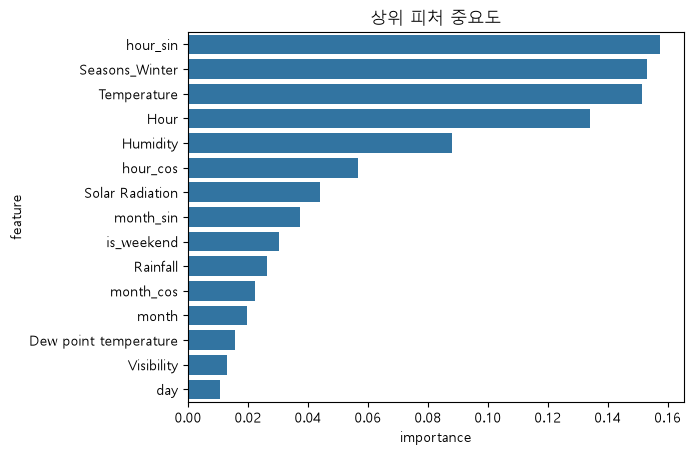

In [36]:
def get_feature_names(preprocessor):
    names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue
        if hasattr(transformer, 'named_steps') and 'onehot' in transformer.named_steps:
            onehot = transformer.named_steps['onehot']
            names.extend(onehot.get_feature_names_out(cols))
        else:
            names.extend(cols)
    return np.array(names)

if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    feature_names = get_feature_names(best_model.named_steps['preprocess'])
    importances = best_model.named_steps['model'].feature_importances_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    display(importance_df.head(20))

    sns.barplot(data=importance_df.head(15), x='importance', y='feature')
    plt.title('상위 피처 중요도')
    plt.show()
else:
    print(f'{best_model_name} 모델은 feature_importances_ 속성을 제공하지 않습니다.')

현재 최고 모델이 결정트리가 아니므로, 결정트리 튜닝 모델을 별도로 시각화합니다.


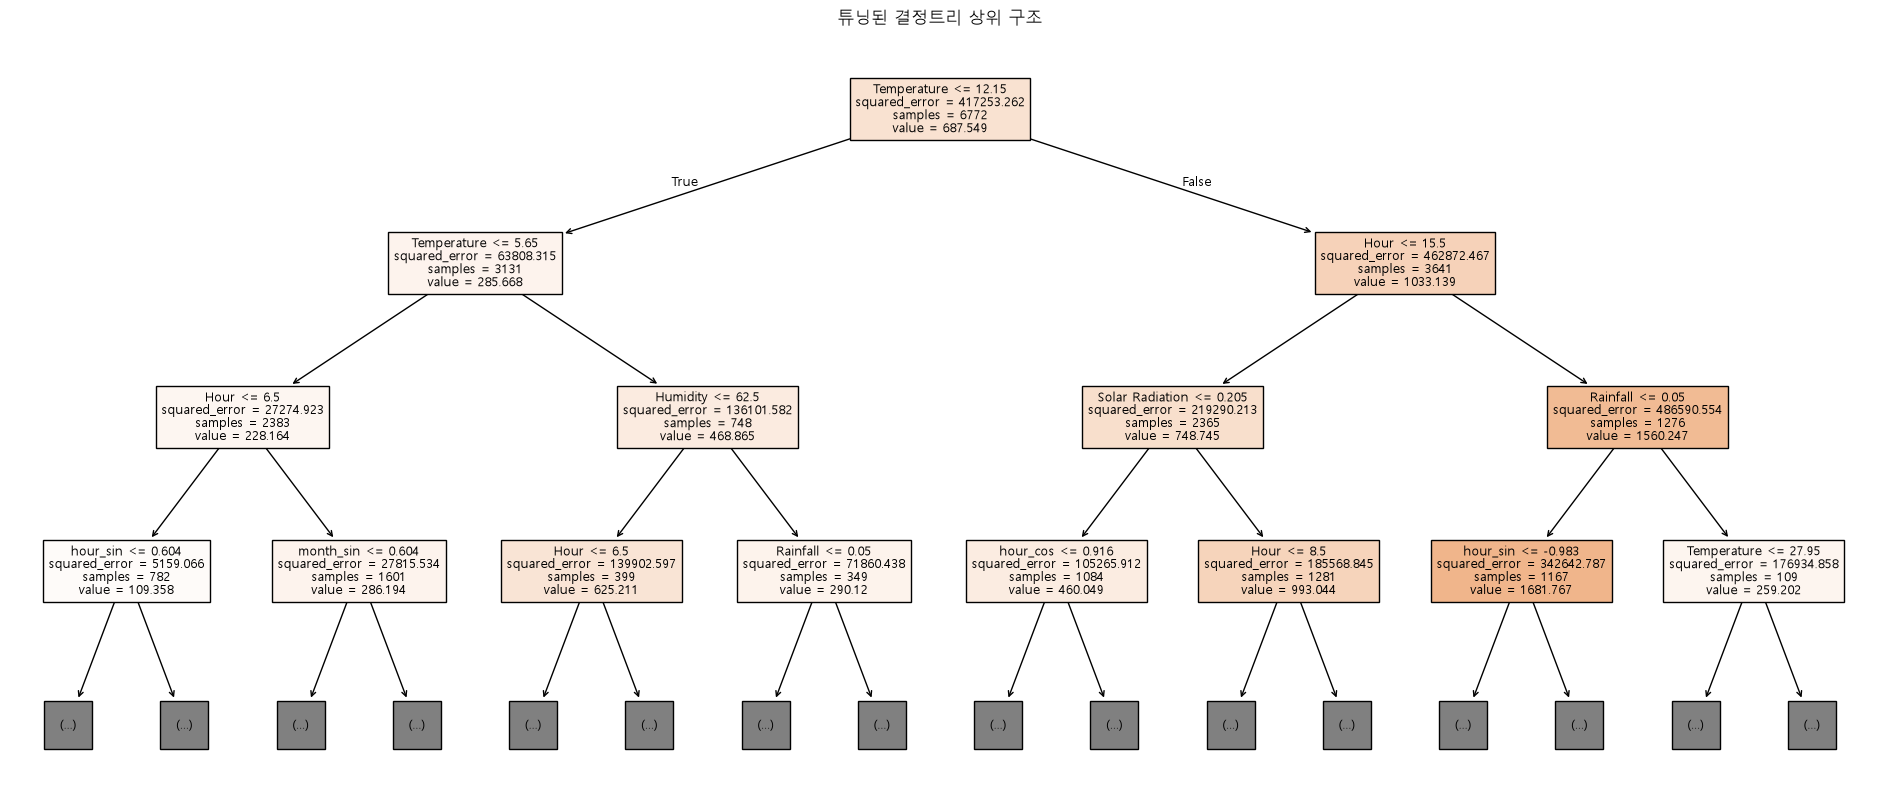

In [37]:
if best_model_name == 'DecisionTree_Tuned':
    tree_model = best_model.named_steps['model']
    feature_names = get_feature_names(best_model.named_steps['preprocess'])

    plt.figure(figsize=(24, 10))
    plot_tree(
        tree_model,
        max_depth=3,
        feature_names=feature_names,
        filled=True,
        fontsize=9
    )
    plt.title('튜닝된 결정트리 상위 구조')
    plt.show()
else:
    print('현재 최고 모델이 결정트리가 아니므로, 결정트리 튜닝 모델을 별도로 시각화합니다.')
    tree_model = dt_grid.best_estimator_.named_steps['model']
    feature_names = get_feature_names(dt_grid.best_estimator_.named_steps['preprocess'])

    plt.figure(figsize=(24, 10))
    plot_tree(
        tree_model,
        max_depth=3,
        feature_names=feature_names,
        filled=True,
        fontsize=9
    )
    plt.title('튜닝된 결정트리 상위 구조')
    plt.show()

### 정리
1. 모델 성능은 기준선 모델부터 비교
    - DummyRegressor 보다 성능이 좋아야 의미 있는 모델이라고 볼 수 있음
2. 시간 데이터는 랜덤 분할을 하지 않음
    - 자전거 수요, 매출, 방문자 수, 재고 수요 같은 데이터는 시간 순서가 중요
    - 미래 데이터가 학습에 섞이면 실제보다 성능이 좋아 보일 수 있음
3. 결정트리는 이해하기 쉽지만 과적합되기 쉬움
    - 결정트리는 설명용으로 좋지만, 단일 결정트리는 데이터 변화에 민감하며 과적합되게 쉬움
4. 평가 지표는 하나만 보면 안됨
    - MAE, RMSE(MSE), R2 등 확인
5. 피처 중요도는 원인 분석이 아님
    - 피처 중요도가 높다고 해서 그 변수가 수요를 직접적으로 증가시킨다는 뜻은 아님
    - 예를 들어 온도가 중요하다고 해서 온도를 올리면 수요가 오른다는 식으로 해석하면 안됨